In [40]:
# In this notebook we examine lidar feature importance -- particularly for thin, single-layer liquid cloud cases.
# 08/29/21

In [41]:
from pathlib import Path
import xarray as xr
import numpy as np
import tensorflow as tf
import keras as K
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any
from plot_utils import cblind_cmap
from tqdm.auto import tqdm
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm

IMPORTANCE_PATH = Path().resolve().parent / "analysis/data/importance"

plt.style.use("style.mplstyle")

PHASES = ["liquid", "ice", "mixed", "drizzle", "liq_driz", "rain", "snow"]
letter_labels = [f"({letter})" for letter in "abcdefghijklmnopqrstuvwxyz"]

cmap = cblind_cmap.copy()
cmap["avg"] = "black"

phases = [
    "liquid", 
    "ice", 
    "mixed", 
    "drizzle", 
    "liq_driz", 
    "rain", 
    "snow",
]
models = {
    "cnn": "CNN",
    "mlp_balanced": "MLP",
    "rf_balanced": "RF",
}

feature_name_map = {
    "mpl_backscatter": r"MPL $\beta$",
    "mpl_linear_depol_ratio": "MPL Dep",
    "reflectivity": "$Z_e$ (dBZ)",
    "mean_doppler_velocity": "MDV (m/s)",
    "spectral_width": "W (m/s)",
    "radar_linear_depolarization_ratio": "Radar Dep",
    "mwrret1liljclou_be_lwp": "LWP (g/$m^2$)",
    "temp": r"T ($\degree C$)",
}

CNN_FEATURES = [  # order matters
    "cloud_flag",
    "temp",
    "mpl_backscatter",
    "mpl_linear_depol_ratio",
    "reflectivity",
    "radar_linear_depolarization_ratio",
    "spectral_width",
    "mean_doppler_velocity",
    "mwrret1liljclou_be_lwp",
]

PHASE_MAP = {
    0: "clear",
    1: "liquid",
    2: "ice",
    3: "mixed",
    4: "drizzle",
    5: "liq_driz",
    6: "rain",
    7: "snow",
}
PHASE_NUMS = [1, 2, 3, 4, 5, 6, 7]
PHASES = [PHASE_MAP[i] for i in PHASE_NUMS]

In [42]:
def load_importances(_models: list[str] | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Loads phase importance files for each model and returns a new dataframe with
    columns: "feature", "importance", "model". Also does this for the phase-height files.
    Returns the combined phase importance dataframe and the combined phase-height
    importance dataframe."""
    _models = ["cnn", "mlp_balanced", "rf_balanced"] if _models is None else _models

    _p_i_dfs = []
    for _model in _models:
        df = pd.read_parquet(IMPORTANCE_PATH / f"{_model}_importance.parquet")
        df["model"] = _model
        df["feature"] = pd.Categorical(
            df["feature"].map(feature_name_map),
            categories=feature_name_map.values(),
            ordered=True,
        )
        df = df.sort_values("feature").rename(columns={"acc": "recall"})
        _p_i_dfs.append(df)
    p_i_df = pd.concat(_p_i_dfs)

    _p_h_i_dfs = []
    for _model in _models:
        df = pd.read_parquet(IMPORTANCE_PATH / f"{_model}_height_importance.parquet")
        df["model"] = _model
        df = df.rename(columns={"acc": "recall", "variable": "feature"})
        df["feature"] = pd.Categorical(
            df["feature"].map(feature_name_map),
            categories=feature_name_map.values(),
            ordered=True,
        )
        df = df.sort_values("feature")
        _p_h_i_dfs.append(df)
    p_h_i_df = pd.concat(_p_h_i_dfs)
    return p_i_df.reset_index(), p_h_i_df.reset_index()

i_df, i_height_df = load_importances()

i_height_df

,index,feature,importance,phase,height,model
0,766,MPL $\beta$,NaN,snow,11.62,cnn
1,762,MPL $\beta$,-0.000000,overall,11.50,cnn
2,763,MPL $\beta$,-0.000000,overall,11.53,cnn
3,764,MPL $\beta$,-0.000000,overall,11.56,cnn
4,765,MPL $\beta$,-0.000000,overall,11.59,cnn
...,...,...,...,...,...,...
73723,133,T ($\degree C$),0.003045,overall,4.15,rf_balanced
73724,134,T ($\degree C$),0.002922,overall,4.18,rf_balanced
73725,135,T ($\degree C$),0.002827,overall,4.21,rf_balanced
73726,383,T ($\degree C$),NaN,mixed,11.65,rf_balanced


In [43]:
def is_valid_chunk(chunk: xr.Dataset, n_time: int):
    has_enough_time = len(chunk["time"]) >= n_time
    has_enough_clouds = (chunk["cloud_phase_mplgr"] > 0).sum() > 100
    no_unknowns = (chunk["cloud_phase_mplgr"] != 8).all()
    return has_enough_time and has_enough_clouds and no_unknowns

def extract_samples(
    dataset: xr.Dataset, chunk_size: tuple[int, int] | None = None
) -> xr.Dataset:
    """Returns a dataset with a primary coordinate of sample (start datetime)"""
    if chunk_size is None:
        chunk_size = (128, 384)  # time X height

    n_time, n_height = chunk_size

    time_min = dataset["time"].min().values
    time_max = dataset["time"].max().values
    full_time_range = pd.date_range(start=time_min, end=time_max, freq="30s")  # type: ignore
    ds = dataset.reindex({"time": full_time_range}, fill_value=np.nan)

    chunks: list[xr.Dataset] = []
    for i in tqdm(range(len(ds["time"]) // n_time)):
        chunk = ds.isel(
            time=slice(i * n_time, (i + 1) * n_time),
            height=slice(0, n_height),
        )
        if not is_valid_chunk(chunk, n_time=n_time):
            continue

        # Create time and height index dimensions for the chunk
        chunk["time_idx"] = xr.DataArray(np.arange(n_time), dims=["time"])
        chunk["height_idx"] = xr.DataArray(np.arange(n_height), dims=["height"])

        # Make the data be indexed by the new index values, but preserve the original
        # time and height coords as data values.
        chunk = chunk.swap_dims({"time": "time_idx", "height": "height_idx"})
        chunk["time_value"] = xr.DataArray(chunk["time"].values, dims=["time_idx"])
        chunk["height_value"] = xr.DataArray(
            chunk["height"].values, dims=["height_idx"]
        )
        chunk = chunk.drop_vars(["time", "height"])

        # Add the first time value as the sample dimension index
        chunk = chunk.expand_dims("sample").assign_coords(
            sample=[chunk["time_value"].values[0]]
        )
        chunks.append(chunk)
    out = xr.concat(chunks, dim="sample")
    for var_name in CNN_FEATURES:
        out[var_name] = (
            out[var_name].fillna(-9999).astype(np.float32)
        )  # float16 not supported

    out["cloud_flag"] = out["cloud_flag"].fillna(-1).astype(np.int8)
    out["cloud_phase_mplgr"] = out["cloud_phase_mplgr"].fillna(0).astype(np.int8)

    return out

def to_cnn_inputs(ds: xr.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """Takes a chunked dataset and converts it into
    X has shape (samples, time, height, len(features))
    y has shape (samples, time, height, 1), with values 0-7
    """

    normalizations = {
        "cloud_flag": lambda x: np.clip(x, 0, 1),  # 0=clear, 1=cloud
        "temp": lambda x: (np.clip(x, -100, 50) + 30) / 30,
        "mpl_backscatter": lambda x: (np.log(np.clip(x, 1e-8, 1e4)) + 6) / 8,
        "mpl_linear_depol_ratio": lambda x: np.clip(x, 0, 1) * 2 - 1,
        "reflectivity": lambda x: (np.clip(x, -70, 70) + 20) / 30,
        "radar_linear_depolarization_ratio": lambda x: np.clip(x + 20, -20, 20) / 6,
        "spectral_width": lambda x: np.clip(x * 5, -1, 4) - 0.5,
        "mean_doppler_velocity": lambda x: np.clip(x + 0.5, -8, 8) / 2,
        "mwrret1liljclou_be_lwp": lambda x: (np.log(np.clip(x, 0.1, 2000)) - 3) / 2,
    }

    y = np.expand_dims(ds["cloud_phase_mplgr"].values, axis=-1)
    X = np.stack(
        [
            normalizations[v](ds[v].fillna(-9999).values)  # -9999 will be clipped
            for v in CNN_FEATURES
        ],
        axis=-1,
    )
    return X, y

def cnn_p(model: K.Model, X: np.ndarray) -> np.ndarray:
    # The CNN models return a probability vector like (samples, time, height, phase)
    # The phase dimension includes clear sky probabilities, but we know if the sky
    # is clear because of the 'cloud_flag' input (index 0 in channel dim of X), so
    # we take out clear sky from proba (index 0 in phase dim of proba) and manually
    # set clear sky indexes to clear in the pred vector. This prevents the model
    # from accidentally predicting clear sky when it is actually cloudy, essentially
    # giving us whatever the second-most-likely phase would have been in such cases.
    proba = model.predict(X, verbose=0, batch_size=4)  # type: ignore
    wo_clear_sky_proba = proba[:, :, :, 1:]
    pred = np.argmax(wo_clear_sky_proba, axis=-1) + 1
    pred[X.take(0, -1) == 0] = 0
    return pred

def phase_acc_scores(
    y_pred: np.ndarray, phase_idxs: dict[int, Any]
) -> dict[str, float]:
    scores: dict[str, float] = {}
    for phase_id, idxs in phase_idxs.items():
        if not len(idxs[0]):
            scores[PHASE_MAP[phase_id]] = np.nan
            continue
        scores[PHASE_MAP[phase_id]] = (y_pred[idxs] == phase_id).mean()
    scores["avg"] = np.nanmean(list(scores.values()))  # type: ignore
    return scores


def phase_acc_height_scores(
    y_true: np.ndarray, y_pred: np.ndarray, phase_values: dict[int, Any]
) -> pd.DataFrame:
    # y_true/pred should have shape (samples, 128, 384)
    matches = y_true == y_pred
    scores = pd.DataFrame({"overall": matches.mean(axis=(0, 1))})
    for phase_id, of_phase_type in phase_values.items():
        numerator = (matches & of_phase_type).sum(axis=(0, 1))
        denominator = of_phase_type.sum(axis=(0, 1))
        acc_for_phase = np.full_like(numerator, fill_value=np.nan, dtype=float)
        np.divide(numerator, denominator, out=acc_for_phase, where=denominator > 100)
        scores[PHASE_MAP[phase_id]] = acc_for_phase
    scores["overall"] = matches.mean(axis=(0, 1))
    return scores


def importance_from_scores(
    permuted_scores: dict[str, Any], phase_baseline: dict[str, float]
) -> pd.DataFrame:
    phase_importance_df = pd.DataFrame.from_dict(permuted_scores, orient="columns")
    phase_importance_df = (
        phase_importance_df.reset_index(names="phase")
        .melt(id_vars="phase", var_name="feature", value_name="acc")
        .set_index("phase")
    )
    phase_importance_df["importance"] = (
        phase_importance_df.reset_index()
        .apply(lambda row: phase_baseline[row["phase"]] - row["acc"], axis=1)
        .set_axis(phase_importance_df.index)
    )
    return phase_importance_df


def importance_from_height_scores(
    permuted_height_scores: dict[str, Any], phase_height_baseline: pd.DataFrame
) -> pd.DataFrame:
    phase_height_dfs = {}
    for phase in list(PHASES) + ["overall"]:
        df = pd.DataFrame({k: v[phase] for k, v in permuted_height_scores.items()})
        df = -df.subtract(phase_height_baseline[phase], axis=0)
        df = df.reset_index(names=["height_idx"])
        df = df.melt(id_vars=["height_idx"], value_name="importance")
        df["phase"] = phase
        phase_height_dfs[phase] = df
    phase_height_importance_df = pd.concat(phase_height_dfs.values())
    phase_height_importance_df["height"] = 0.16 + (
        0.03 * phase_height_importance_df.pop("height_idx")
    )  # type: ignore
    return phase_height_importance_df

def calculate_importance(
    model: K.Model,
    X_test: np.ndarray,
    y_test: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    # For convenience / performance
    y_flat = y_test.ravel()
    phase_idxs = {phase_id: np.where(y_flat == phase_id) for phase_id in PHASE_NUMS}
    phase_values = {phase_id: (y_test == phase_id) for phase_id in PHASE_NUMS}

    # Baseline predictions
    pred = cnn_p(model, X_test)
    print(pred.shape, y_test.shape)
    y_pred = pred.ravel()

    phase_baseline = phase_acc_scores(y_pred, phase_idxs=phase_idxs)
    phase_height_baseline = phase_acc_height_scores(
        y_test,
        pred,
        phase_values=phase_values,
    )

    permuted_scores = {}  # dict of feature_var:dict[phase:]
    permuted_height_scores = {}  # dict of feature_var:dict[phase:]

    assert len(CNN_FEATURES) == X_test.shape[-1]
    for i, feature_name in tqdm(enumerate(CNN_FEATURES[1:])):
        i = i + 1  # make i start at 1 since we are skipping cloud_flag

        # Permute the selected feature column and make predictions on the test set
        X_permuted = X_test.copy()
        np.random.shuffle(X_permuted[:, :, :, i])
        y_pred_permuted = cnn_p(model, X_permuted)

        # Calculate metrics for the predictions on the permuted dataset
        permuted_scores[feature_name] = phase_acc_scores(
            y_pred_permuted.ravel(),
            phase_idxs=phase_idxs,
        )
        permuted_height_scores[feature_name] = phase_acc_height_scores(
            y_true=y_test,
            y_pred=y_pred_permuted,
            phase_values=phase_values,
        )

    # Consolidate permutation feature importances
    phase_importance_df = importance_from_scores(
        permuted_scores=permuted_scores,
        phase_baseline=phase_baseline,
    )

    # Consolidate permutation feature importances by height
    phase_height_importance_df = importance_from_height_scores(
        permuted_height_scores=permuted_height_scores,
        phase_height_baseline=phase_height_baseline,
    )

    return phase_importance_df, phase_height_importance_df

In [44]:
cnn_vars = CNN_FEATURES + ["cloud_phase_mplgr"]
ds1 = xr.open_dataset("../processing/data/predictions/nsathermocldphaseC1.c1.20210605.000000.nc")
ds2 = xr.open_dataset("../processing/data/predictions/nsathermocldphaseC1.c1.20210606.000000.nc")
dataset = xr.concat([ds1[cnn_vars], ds2[cnn_vars]], dim="time").isel(time=slice(0, 2944))  # 2944/128 = 23

samples = extract_samples(dataset, chunk_size=(128, 384)).load()
X, y = to_cnn_inputs(samples)


print(X.shape)
print(y.shape)

  0%|          | 0/23 [00:00<?, ?it/s]

(23, 128, 384, 9)
(23, 128, 384, 1)


In [45]:
np.unique(y[y!=0], return_counts=True)

(array([1, 2, 3, 4, 5, 6], dtype=int8),
 array([17634, 10520,  9440,   328,  4094,    22]))

In [46]:
# Primary CNN model used in the paper (not the one trained with dropout layers)
model: K.Model = K.models.load_model("../processing/models/cnn.20240429.213223.h5") # type: ignore
df, height_df = calculate_importance(model, X, np.squeeze(y))
df = df.reset_index()
height_df = height_df.rename(columns={"variable": "feature"})
df

(23, 128, 384) (23, 128, 384)


0it [00:00, ?it/s]

,phase,feature,acc,importance
0,liquid,temp,0.809516,-0.002552
1,ice,temp,0.873669,0.000951
2,mixed,temp,0.937394,0.001483
3,drizzle,temp,0.481707,-0.048780
4,liq_driz,temp,0.172692,-0.013190
...,...,...,...,...
59,drizzle,mwrret1liljclou_be_lwp,0.457317,-0.024390
60,liq_driz,mwrret1liljclou_be_lwp,0.153639,0.005862
61,rain,mwrret1liljclou_be_lwp,0.000000,0.000000
62,snow,mwrret1liljclou_be_lwp,NaN,NaN


In [47]:
HEIGHT = 3  # km

overall_height = height_df[(height_df["phase"] == "overall") & (height_df["height"] < HEIGHT)]
overall_height

,feature,importance,phase,height
0,temp,0.000340,overall,0.16
1,temp,-0.000340,overall,0.19
2,temp,-0.000340,overall,0.22
3,temp,-0.000000,overall,0.25
4,temp,-0.001019,overall,0.28
...,...,...,...,...
2778,mwrret1liljclou_be_lwp,0.000340,overall,2.86
2779,mwrret1liljclou_be_lwp,-0.000000,overall,2.89
2780,mwrret1liljclou_be_lwp,-0.000000,overall,2.92
2781,mwrret1liljclou_be_lwp,-0.000000,overall,2.95


/var/folders/5n/ycnfz3351hj0gy28x0pbgbhr0000gn/T/ipykernel_52516/3656683110.py:111: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


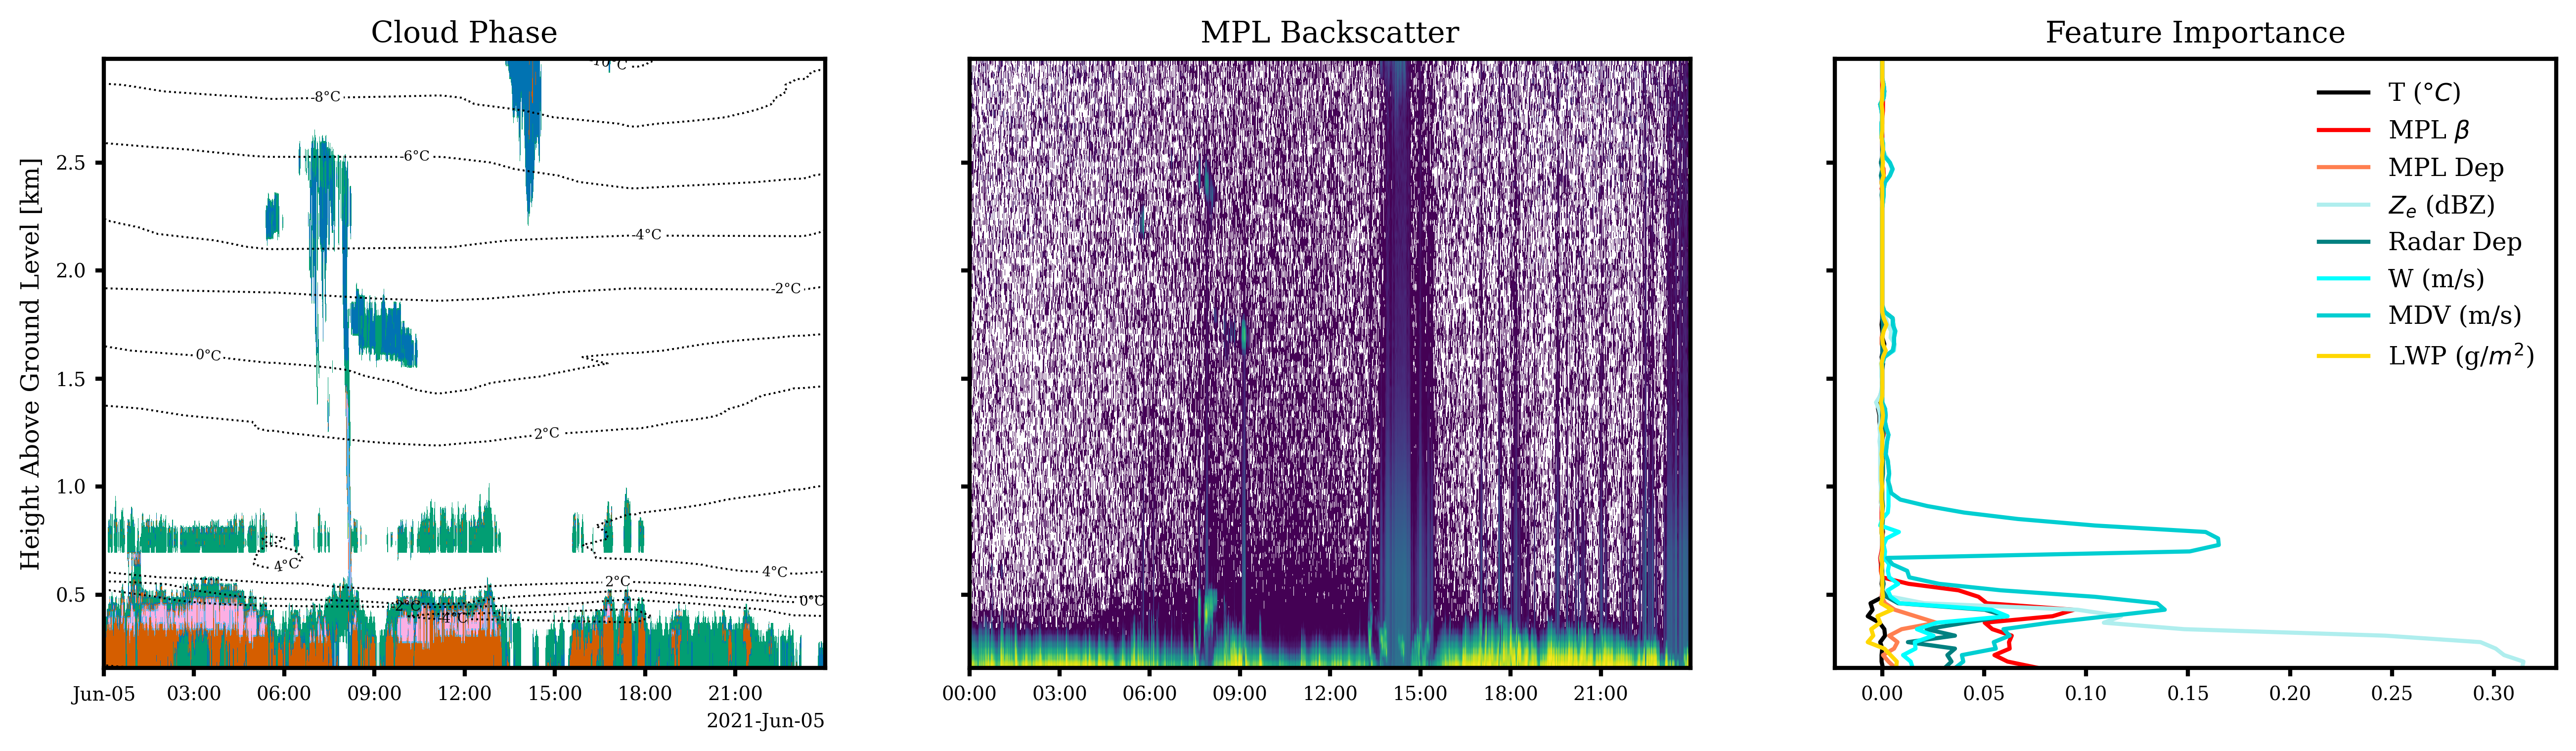

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True, figsize=(16,4))

feature_cmap = {
    "temp": "black",
    "mpl_backscatter": "red",
    "mpl_linear_depol_ratio": "coral",
    "reflectivity": "paleturquoise",
    "radar_linear_depolarization_ratio": "teal",
    "spectral_width": "aqua",
    "mean_doppler_velocity": "darkturquoise",
    "mwrret1liljclou_be_lwp": "gold",
}
feature_name_map = {
    "mpl_backscatter": r"MPL $\beta$",
    "mpl_linear_depol_ratio": "MPL Dep",
    "reflectivity": "$Z_e$ (dBZ)",
    "mean_doppler_velocity": "MDV (m/s)",
    "spectral_width": "W (m/s)",
    "radar_linear_depolarization_ratio": "Radar Dep",
    "mwrret1liljclou_be_lwp": "LWP (g/$m^2$)",
    "temp": r"T ($\degree C$)",
}

# CLOUD PHASE AND ISOTHERMAL LINES
_ds1 = ds1.sel(height=slice(0, HEIGHT))
extent = [
    _ds1.time.values.min(),
    _ds1.time.values.max(),
    _ds1.height.values.min(),
    _ds1.height.values.max(),
]
phases = list(cblind_cmap.keys())[:-1]
cmap = ListedColormap(list(cblind_cmap.values())[:-1])
norm = BoundaryNorm(np.arange(-0.5, len(phases) + 0.5), cmap.N)
im = ax1.imshow(
    _ds1["cloud_phase_mplgr"].T,
    aspect="auto",
    extent=extent,
    origin="lower",
    cmap=cmap,
    norm=norm,
)
contours = _ds1["temp"].plot.contour(ax=ax1, x="time", vmin=-30, vmax=30, levels=31, colors=["black"], linestyles="dotted", linewidths=0.7)
ax1.clabel(contours, fontsize=5, fmt=lambda x: f"{x:.0f}°C")
ax1.set_xlabel("")
ax1.set_ylabel("Height Above Ground Level [km]")
ax1.set_title("Cloud Phase")


# Predicted cloud phase with isothermal lines
# mpl_backscat_snr = _ds1['mpl_backscatter_snr'].data
mpl_backscat = _ds1['mpl_backscatter'].data * (_ds1['height'].data**2)
# mpl_backscat[mpl_backscat <= 0] = np.nan
# mpl_backscat[mpl_backscat_snr <= 0.4] = np.nan
ax2.imshow(
    # ds[var_name].T,
    mpl_backscat.T,
    aspect="auto",
    cmap="viridis",
    extent=extent,
    origin="lower",
    norm=LogNorm(vmin=1e-2, vmax=1e2),
)
ax2.set_title("MPL Backscatter")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax2.set_xticks()

# extent = [
#     _ds1.time.values.min(),
#     _ds1.time.values.max(),
#     _ds1.height.values.min(),
#     _ds1.height.values.max(),
# ]
# phases = list(cblind_cmap.keys())[:-1]
# cmap = ListedColormap(list(cblind_cmap.values())[:-1])
# norm = BoundaryNorm(np.arange(-0.5, len(phases) + 0.5), cmap.N)
# im = ax2.imshow(
#     _ds1["cnn"].T,
#     aspect="auto",
#     extent=extent,
#     origin="lower",
#     cmap=cmap,
#     norm=norm,
# )
# contours = _ds1["temp"].plot.contour(ax=ax2, x="time", vmin=-30, vmax=30, levels=31, colors=["black"], linestyles="dotted", linewidths=0.7)
# ax2.clabel(contours, fontsize=5, fmt=lambda x: f"{x:.0f}°C")
# ax2.set_xlabel("")
# ax2.set_title("Predicted [CNN]")

# cbar = fig.colorbar(
#     im,
#     ax=ax1,
#     ticks=np.arange(0, len(phases)),
#     pad=0.01,
#     aspect=5,
# )
# cbar.set_label("")
# cbar.set_ticks(list(range(len(phases))), labels=phases)
# cbar.ax.tick_params(size=0, which="both")

for feature in CNN_FEATURES[1:]:
    overall_height[overall_height["feature"] == feature].plot.line(
        y="height",
        x="importance",
        ax=ax3,
        color=feature_cmap[feature],
        label=feature_name_map[feature],
    )
ax3.set_xlabel("")
ax3.set_title("Feature Importance")
fig.show()

In [49]:
models

{'cnn': 'CNN', 'mlp_balanced': 'MLP', 'rf_balanced': 'RF'}

/var/folders/5n/ycnfz3351hj0gy28x0pbgbhr0000gn/T/ipykernel_52516/2400317440.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


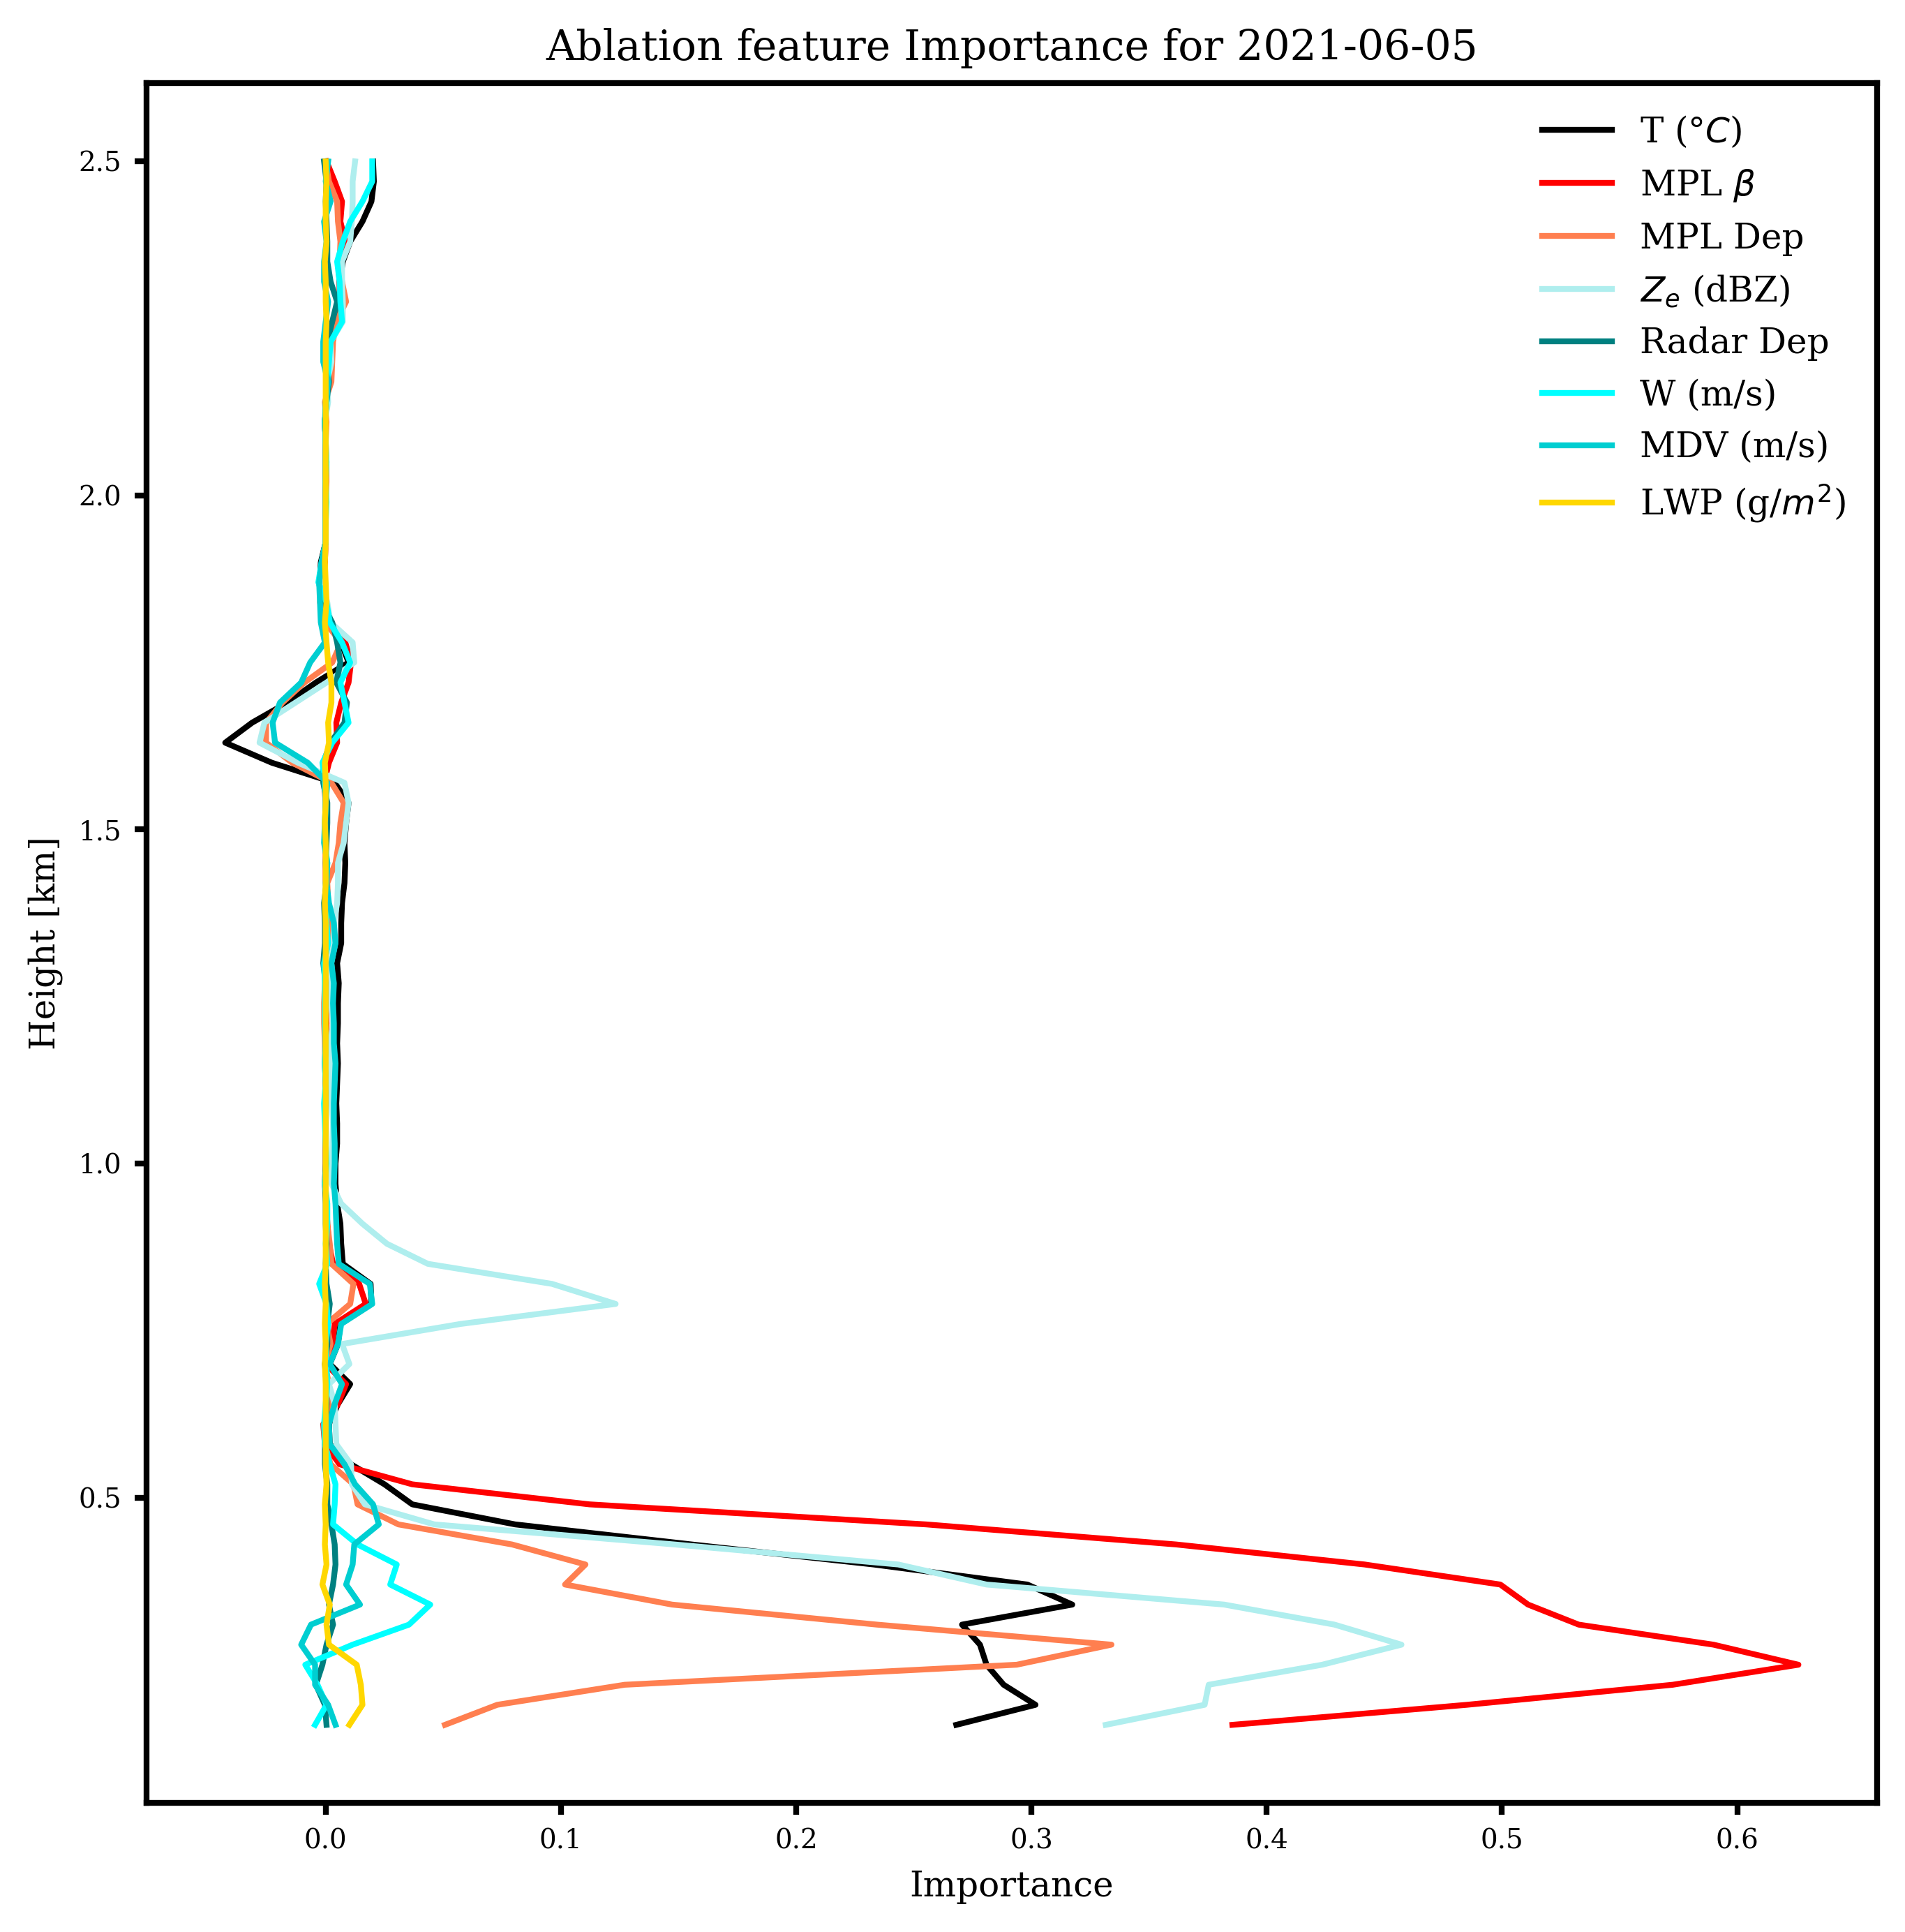

In [50]:
feature_display_map = {
    "sonde": ("temp", r"T ($\degree C$)", "black"),
    "mpl_b": ("mpl_backscatter", r"MPL $\beta$", "red"),
    "mpl_ldr": ("mpl_linear_depol_ratio", "MPL Dep", "coral"),
    "rad_ref": ("reflectivity", "$Z_e$ (dBZ)", "paleturquoise"),
    "rad_ldr": ("radar_linear_depolarization_ratio", "Radar Dep", "teal"),
    "rad_spec": ("spectral_width", "W (m/s)", "aqua"),
    "rad_mdv": ("mean_doppler_velocity", "MDV (m/s)", "darkturquoise"),
    "mwr": ("mwrret1liljclou_be_lwp", "LWP (g/$m^2$)", "gold"),
}

fig, ax = plt.subplots()

height_acc_vec_overall = (ds1["cloud_phase_mplgr"] == ds1["cnn"]).mean(dim="time").sel(height=slice(0, 2.5))
for var, (_, label, color) in feature_display_map.items():
    data = ds1["cnn_"+var].sel(height=slice(0, 2.5))
    
    height_acc_vec = (ds1["cloud_phase_mplgr"] == data).mean(dim="time")
    height_importance_vec = height_acc_vec_overall - height_acc_vec

    ax.plot(height_importance_vec, height_importance_vec.height, label=label, color=color)

ax.legend(loc="best")
ax.set_ylabel("Height [km]")
ax.set_xlabel("Importance")
ax.set_title(f"Ablation feature Importance for {ds1.time.dt.strftime('%Y-%m-%d')[0].item()}")
fig.show()

In [51]:
pred_1yr = pd.read_parquet("../analysis/data/parallel_nsa_cloudy_predictions.parquet")
pred_1yr

cloud_phase cnn_dropout     cnn rf_balanced  \
time                height                                               
2021-01-01 00:57:00 0.16           ice         ice     ice      liquid   
                    0.19           ice         ice     ice      liquid   
                    0.22           ice         ice     ice         ice   
                    0.25           ice         ice     ice      liquid   
2021-01-01 00:57:30 0.16           ice         ice     ice         ice   
...                                ...         ...     ...         ...   
2021-12-31 23:59:30 2.38           ice      liquid  liquid         ice   
                    2.41           ice      liquid  liquid         ice   
                    2.44           ice      liquid  liquid         ice   
                    2.47           ice      liquid  liquid         ice   
                    2.50           ice      liquid  liquid         ice   

                           rf_imbalanced mlp_balanced mlp_imbalanced  \
time                height                                             
2021-01-01 00:57:00 0.16             ice       liquid            ice   
                    0.19             ice          ice            ice   
                    0.22             ice          ice            ice   
                    0.25             ice          ice            ice   
2021-01-01 00:57:30 0.16             ice       liquid            ice   
...                                  ...          ...            ...   
2021-12-31 23:59:30 2.38             ice          ice            ice   
                    2.41             ice          ice            ice   
                    2.44             ice          ice            ice   
                    2.47             ice          ice            ice   
                    2.50             ice          ice            ice   

                            cnn_dropout_confidence  cnn_confidence  \
time                height                                           
2021-01-01 00:57:00 0.16                  0.864284        0.793064   
                    0.19                  0.920299        0.910763   
                    0.22                  0.859795        0.926132   
                    0.25                  0.812101        0.895370   
2021-01-01 00:57:30 0.16                  0.909938        0.861275   
...                                            ...             ...   
2021-12-31 23:59:30 2.38                  0.000000        0.000000   
                    2.41                  0.000000        0.000000   
                    2.44                  0.000000        0.000000   
                    2.47                  0.000000        0.000000   
                    2.50                  0.000000        0.000000   

                            rf_balanced_confidence  ...  mlp_imbalanced_mpl  \
time                height                          ...                       
2021-01-01 00:57:00 0.16                      0.55  ...              liquid   
                    0.19                      0.52  ...                 ice   
                    0.22                      0.55  ...                 ice   
                    0.25                      0.59  ...              liquid   
2021-01-01 00:57:30 0.16                      0.51  ...              liquid   
...                                            ...  ...                 ...   
2021-12-31 23:59:30 2.38                      0.60  ...                 ice   
                    2.41                      0.62  ...                 ice   
                    2.44                      0.73  ...                 ice   
                    2.47                      0.72  ...                 ice   
                    2.50                      0.49  ...                 ice   

                            mlp_imbalanced_mpl_b  mlp_imbalanced_mpl_ldr  \
time                height                                                 
2021-01-01 00:57:00 0.16            

In [52]:
(pred_1yr["cloud_phase"] == pred_1yr["cnn"]).groupby(level="height").mean()

height
0.16     0.887359
0.19     0.903770
0.22     0.908242
0.25     0.912401
0.28     0.913848
           ...   
11.53    1.000000
11.56    1.000000
11.59    1.000000
11.62    1.000000
11.65    1.000000
Length: 384, dtype: float64

  0%|          | 0/8 [00:00<?, ?it/s]

/var/folders/5n/ycnfz3351hj0gy28x0pbgbhr0000gn/T/ipykernel_52516/836762297.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


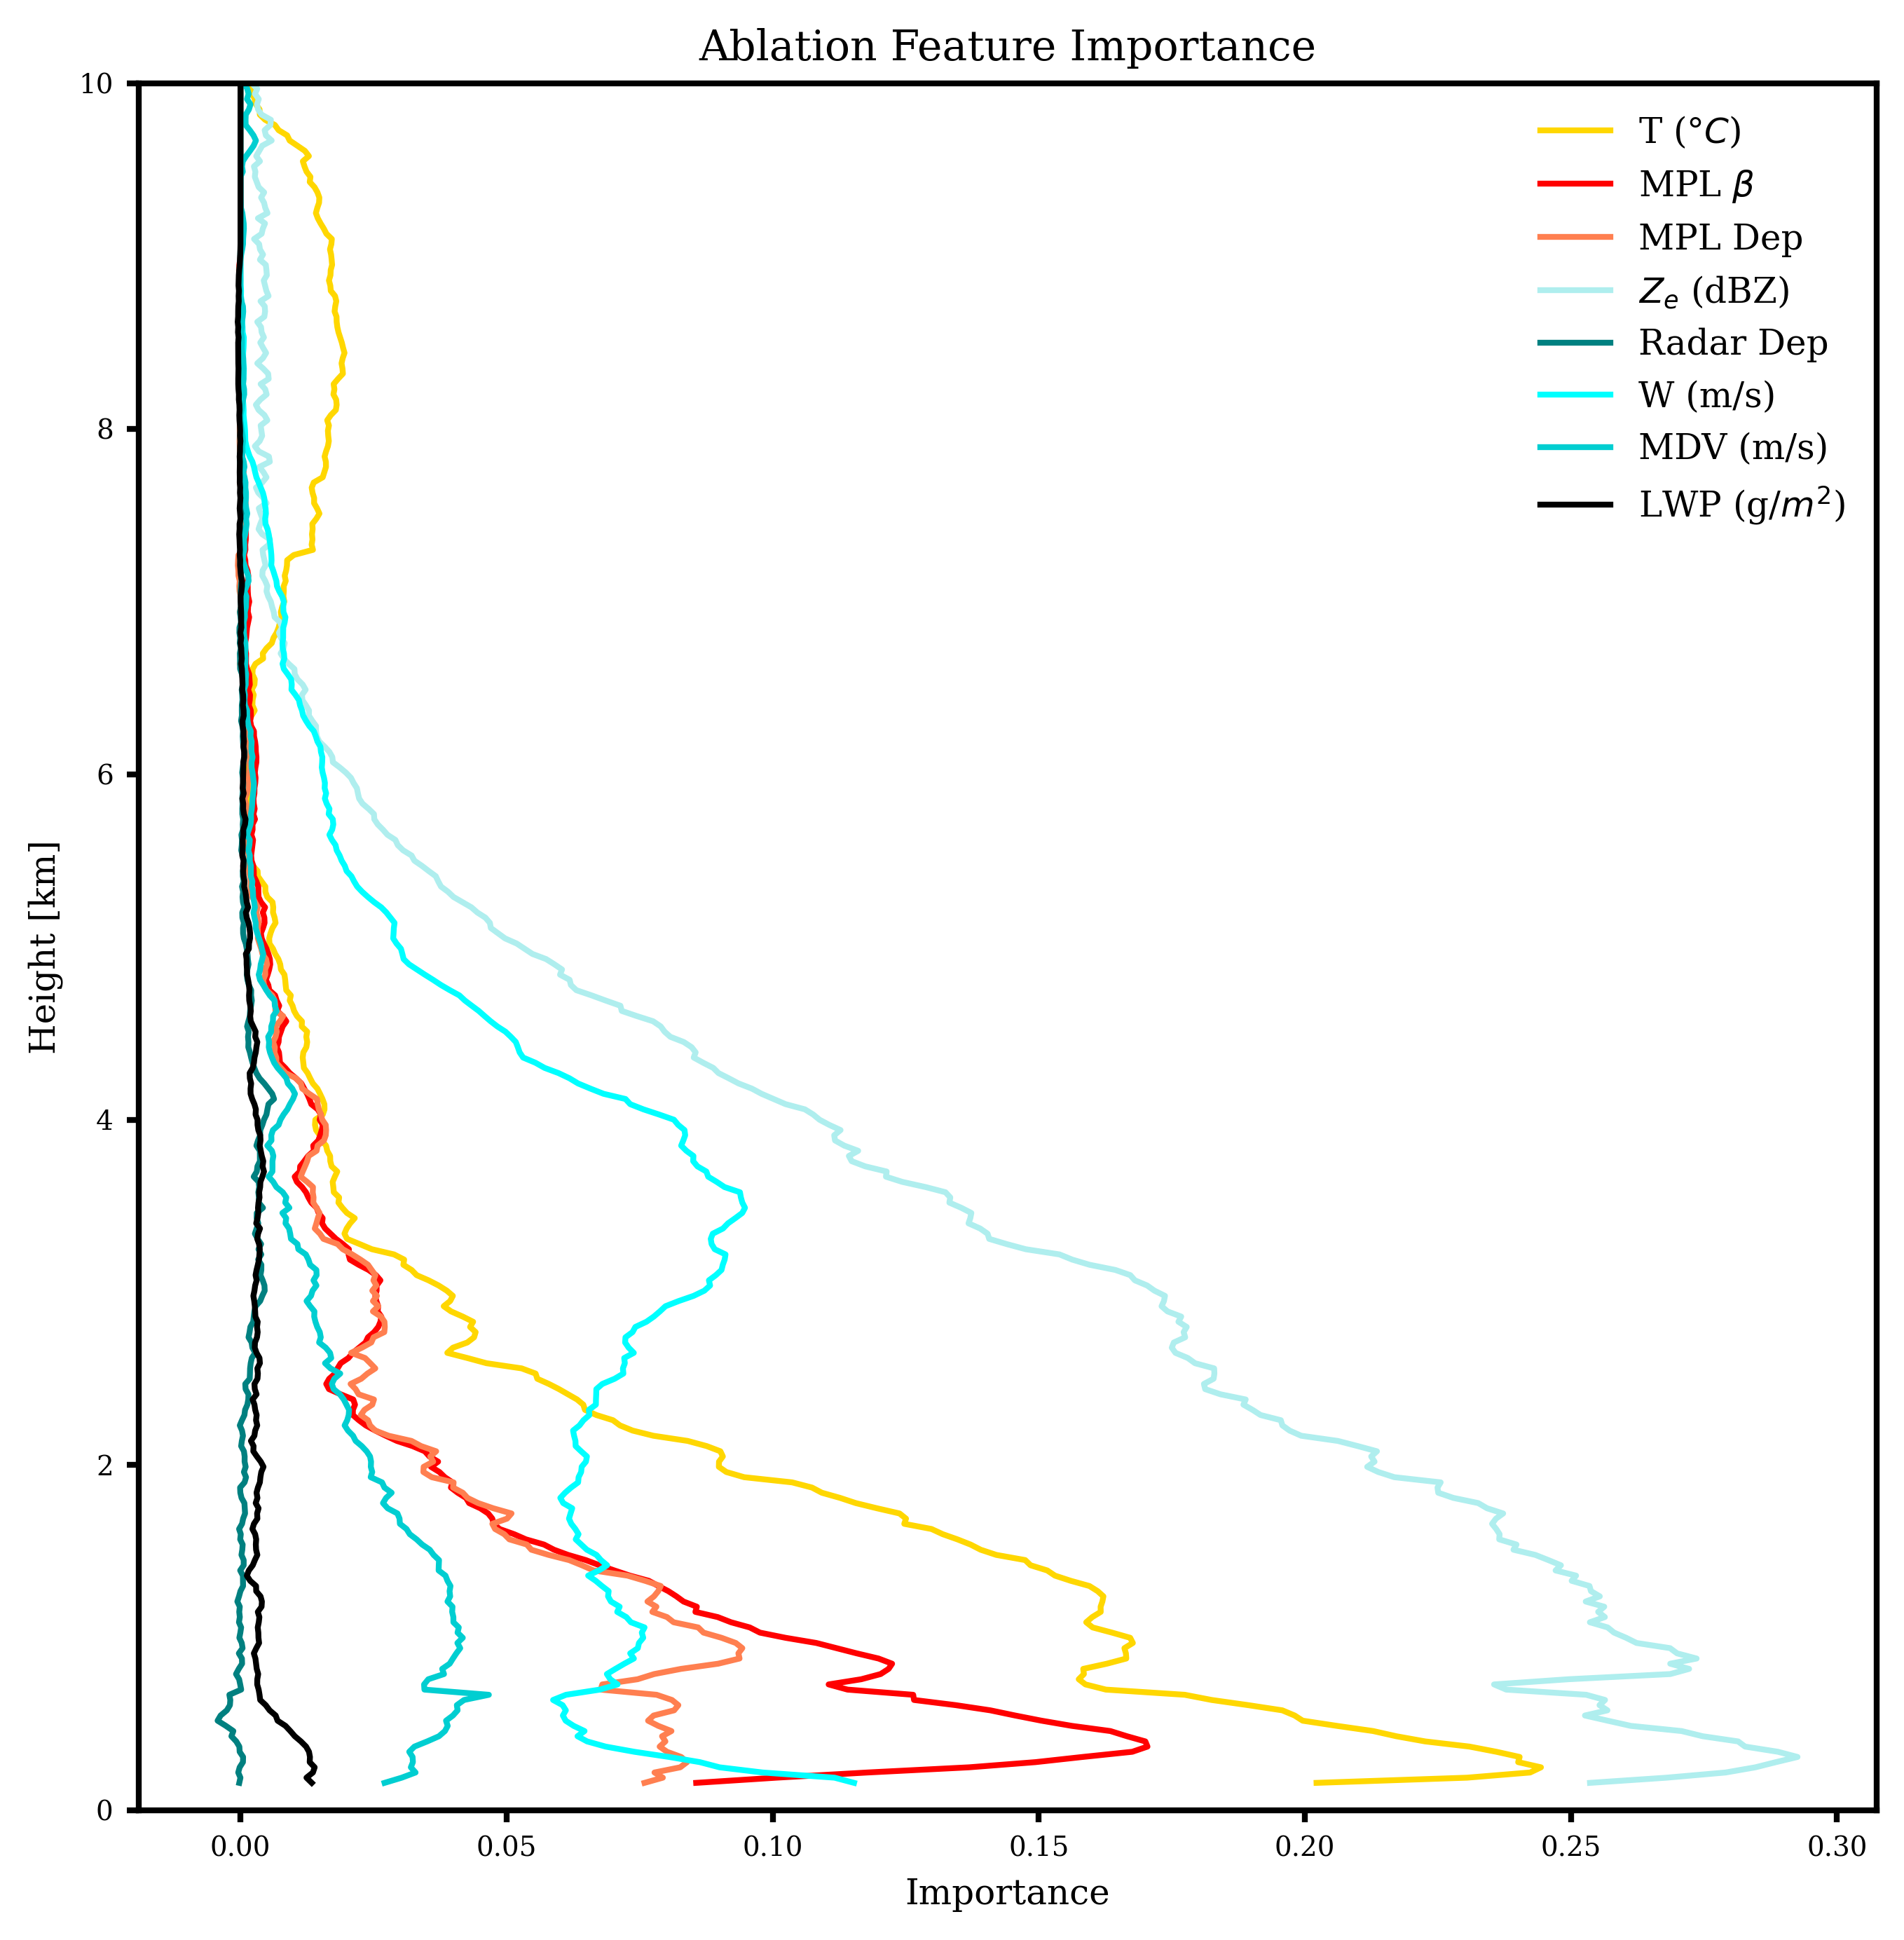

In [53]:
feature_display_map = {
    "sonde": ("temp", r"T ($\degree C$)", "gold"),
    "mpl_b": ("mpl_backscatter", r"MPL $\beta$", "red"),
    "mpl_ldr": ("mpl_linear_depol_ratio", "MPL Dep", "coral"),
    "rad_ref": ("reflectivity", "$Z_e$ (dBZ)", "paleturquoise"),
    "rad_ldr": ("radar_linear_depolarization_ratio", "Radar Dep", "teal"),
    "rad_spec": ("spectral_width", "W (m/s)", "aqua"),
    "rad_mdv": ("mean_doppler_velocity", "MDV (m/s)", "darkturquoise"),
    "mwr": ("mwrret1liljclou_be_lwp", "LWP (g/$m^2$)", "black"),
}

fig, ax = plt.subplots()

height_acc_vec_overall = (pred_1yr["cloud_phase"] == pred_1yr["cnn"]).groupby(level="height").mean()

for var, (_, label, color) in tqdm(feature_display_map.items()):
    data = pred_1yr["cnn_"+var]
    
    height_acc_vec = (pred_1yr["cloud_phase"] == data).groupby(level="height").mean()
    height_importance_vec = height_acc_vec_overall - height_acc_vec

    ax.plot(height_importance_vec, height_importance_vec.index, label=label, color=color)

ax.legend(loc="best")
ax.set_xlabel("Importance")
ax.set_ylabel("Height [km]")
ax.set_title("Ablation Feature Importance")
# ax.set_xlim(0, None)
ax.set_ylim(0, 10)
# ax.set_yscale("log")
fig.show()

/var/folders/5n/ycnfz3351hj0gy28x0pbgbhr0000gn/T/ipykernel_52516/3147436129.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


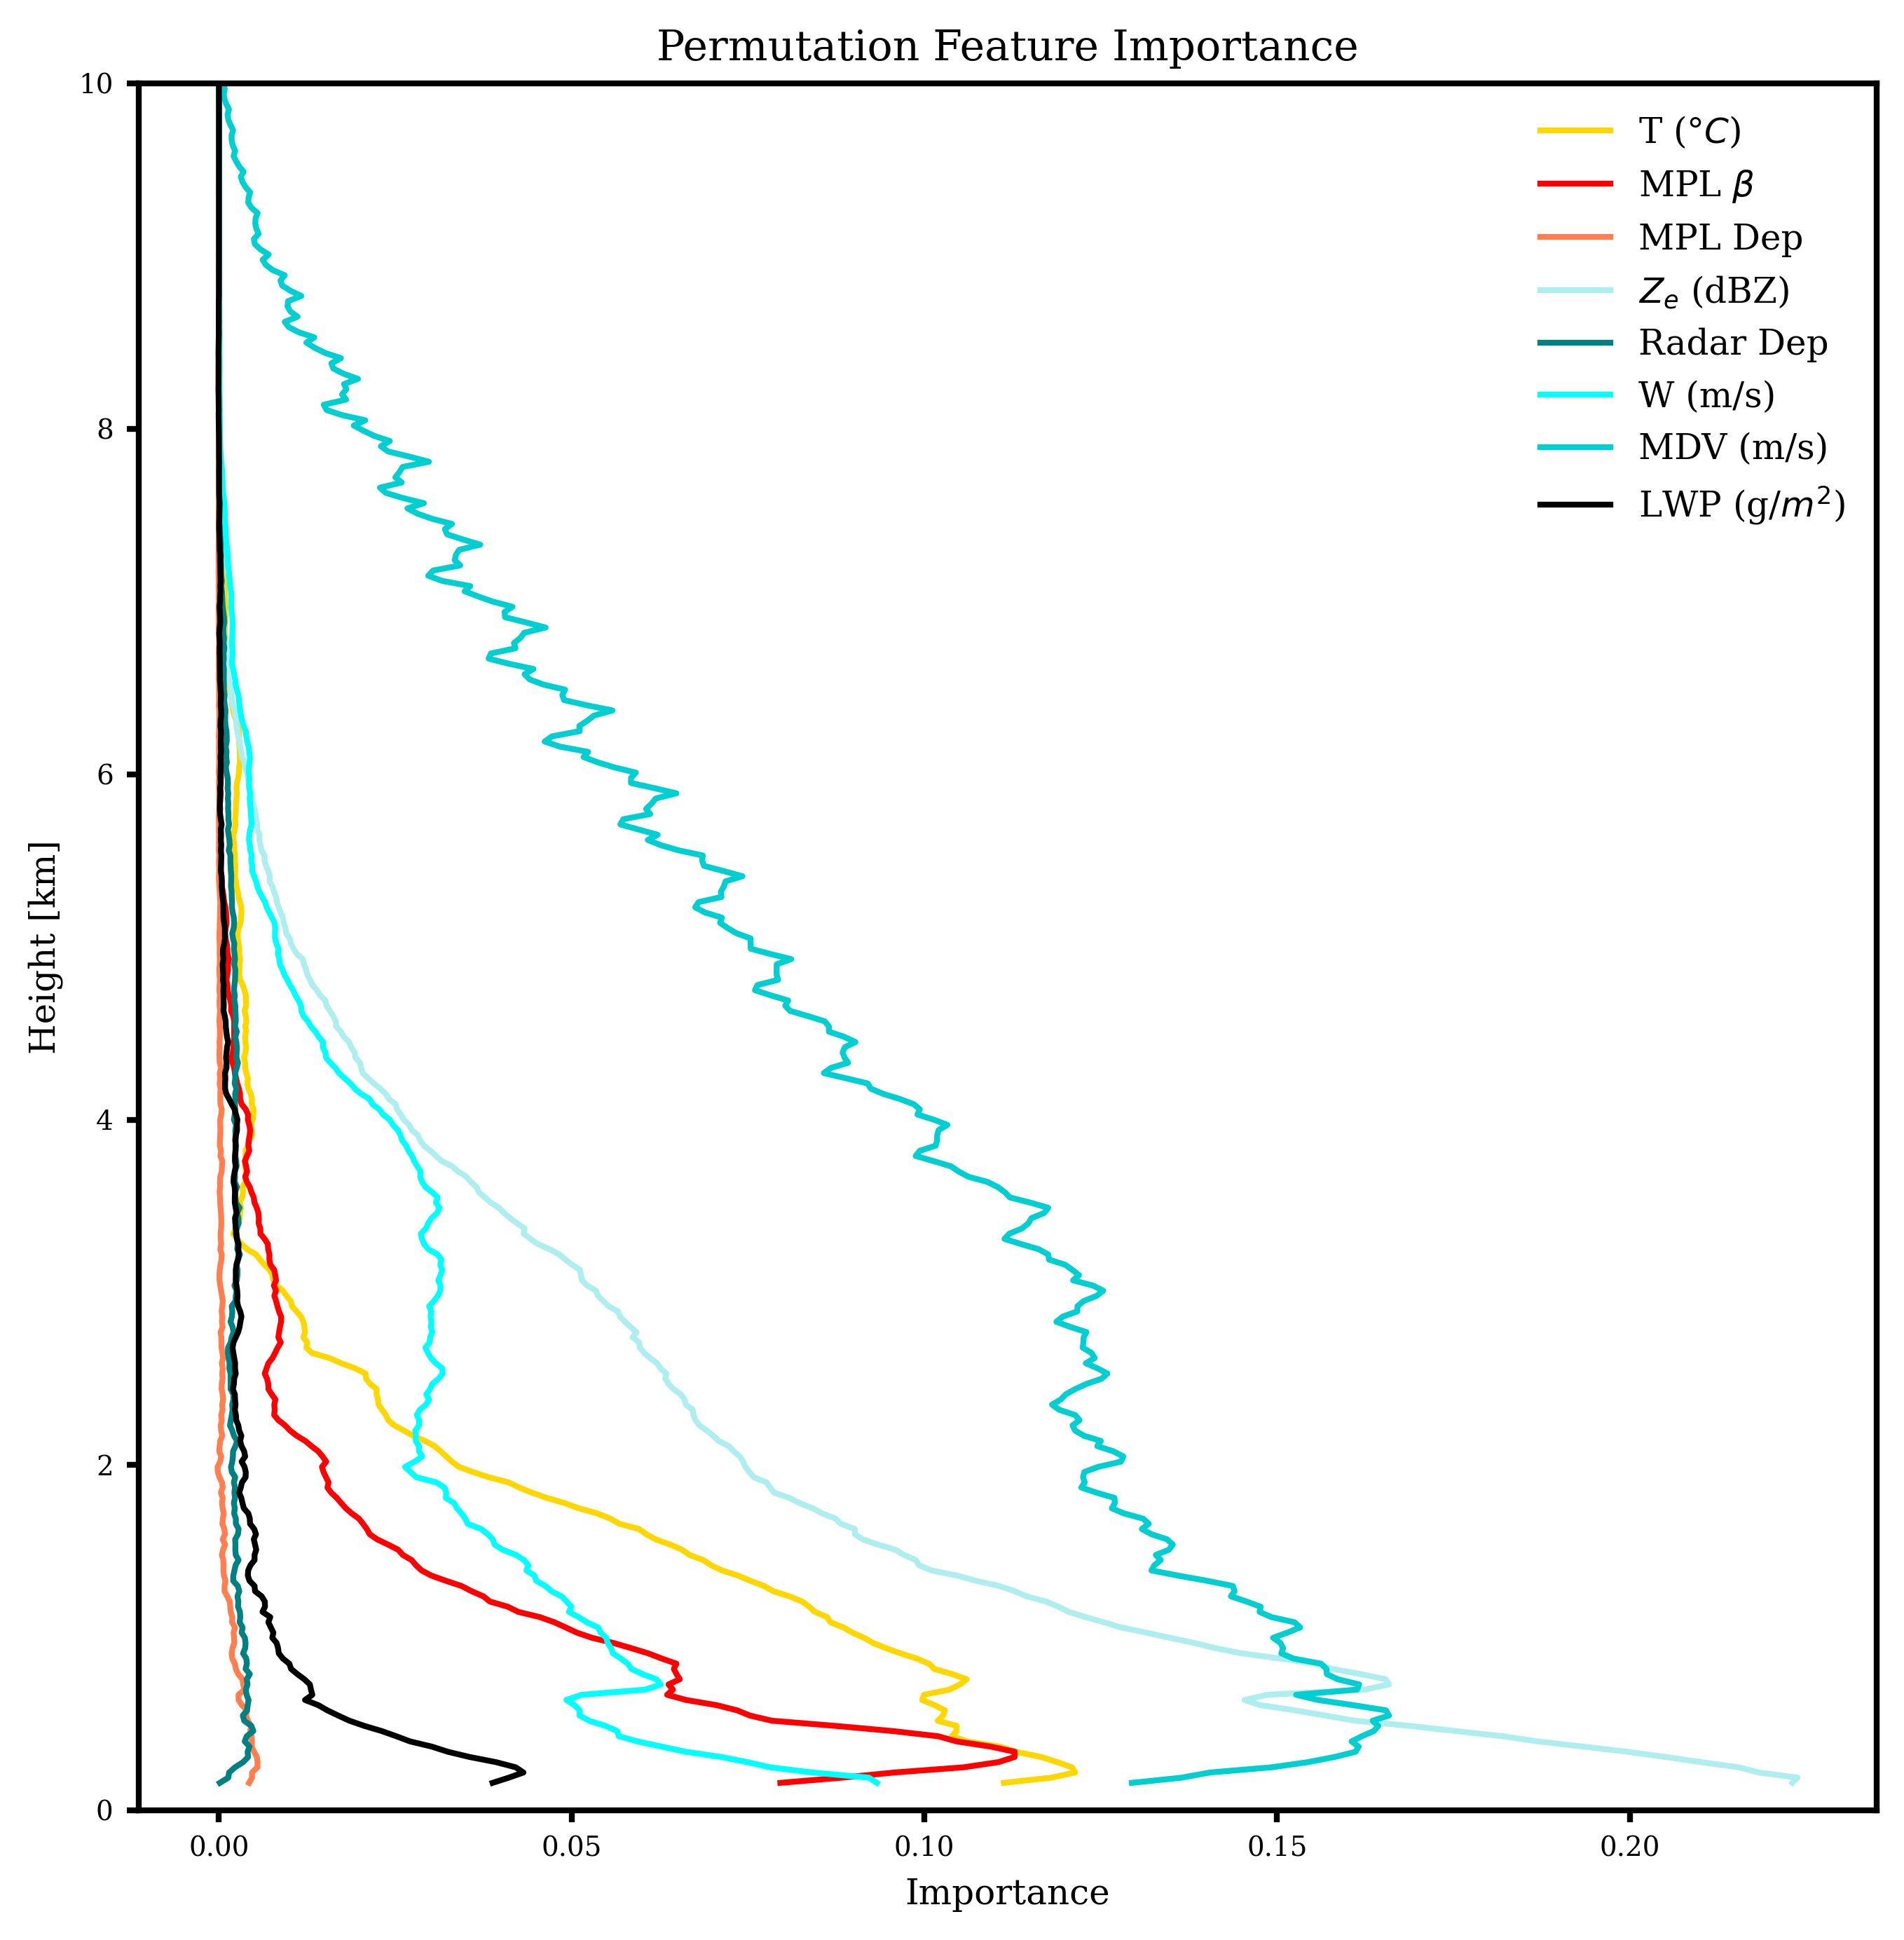

In [54]:
fig, ax = plt.subplots()

ih_df = i_height_df[(i_height_df["model"] == "cnn") & (i_height_df["phase"] == "overall")].dropna()
for _, (_, label, color) in feature_display_map.items():
    data = ih_df[ih_df["feature"] == label].sort_values(by="height")

    ax.plot(data["importance"], data["height"], label=label, color=color)

ax.legend(loc="best")
ax.set_xlabel("Importance")
ax.set_ylabel("Height [km]")
ax.set_title("Permutation Feature Importance")
ax.set_ylim(0, 10)
fig.show()

  0%|          | 0/8 [00:00<?, ?it/s]

/var/folders/5n/ycnfz3351hj0gy28x0pbgbhr0000gn/T/ipykernel_52516/1578521929.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


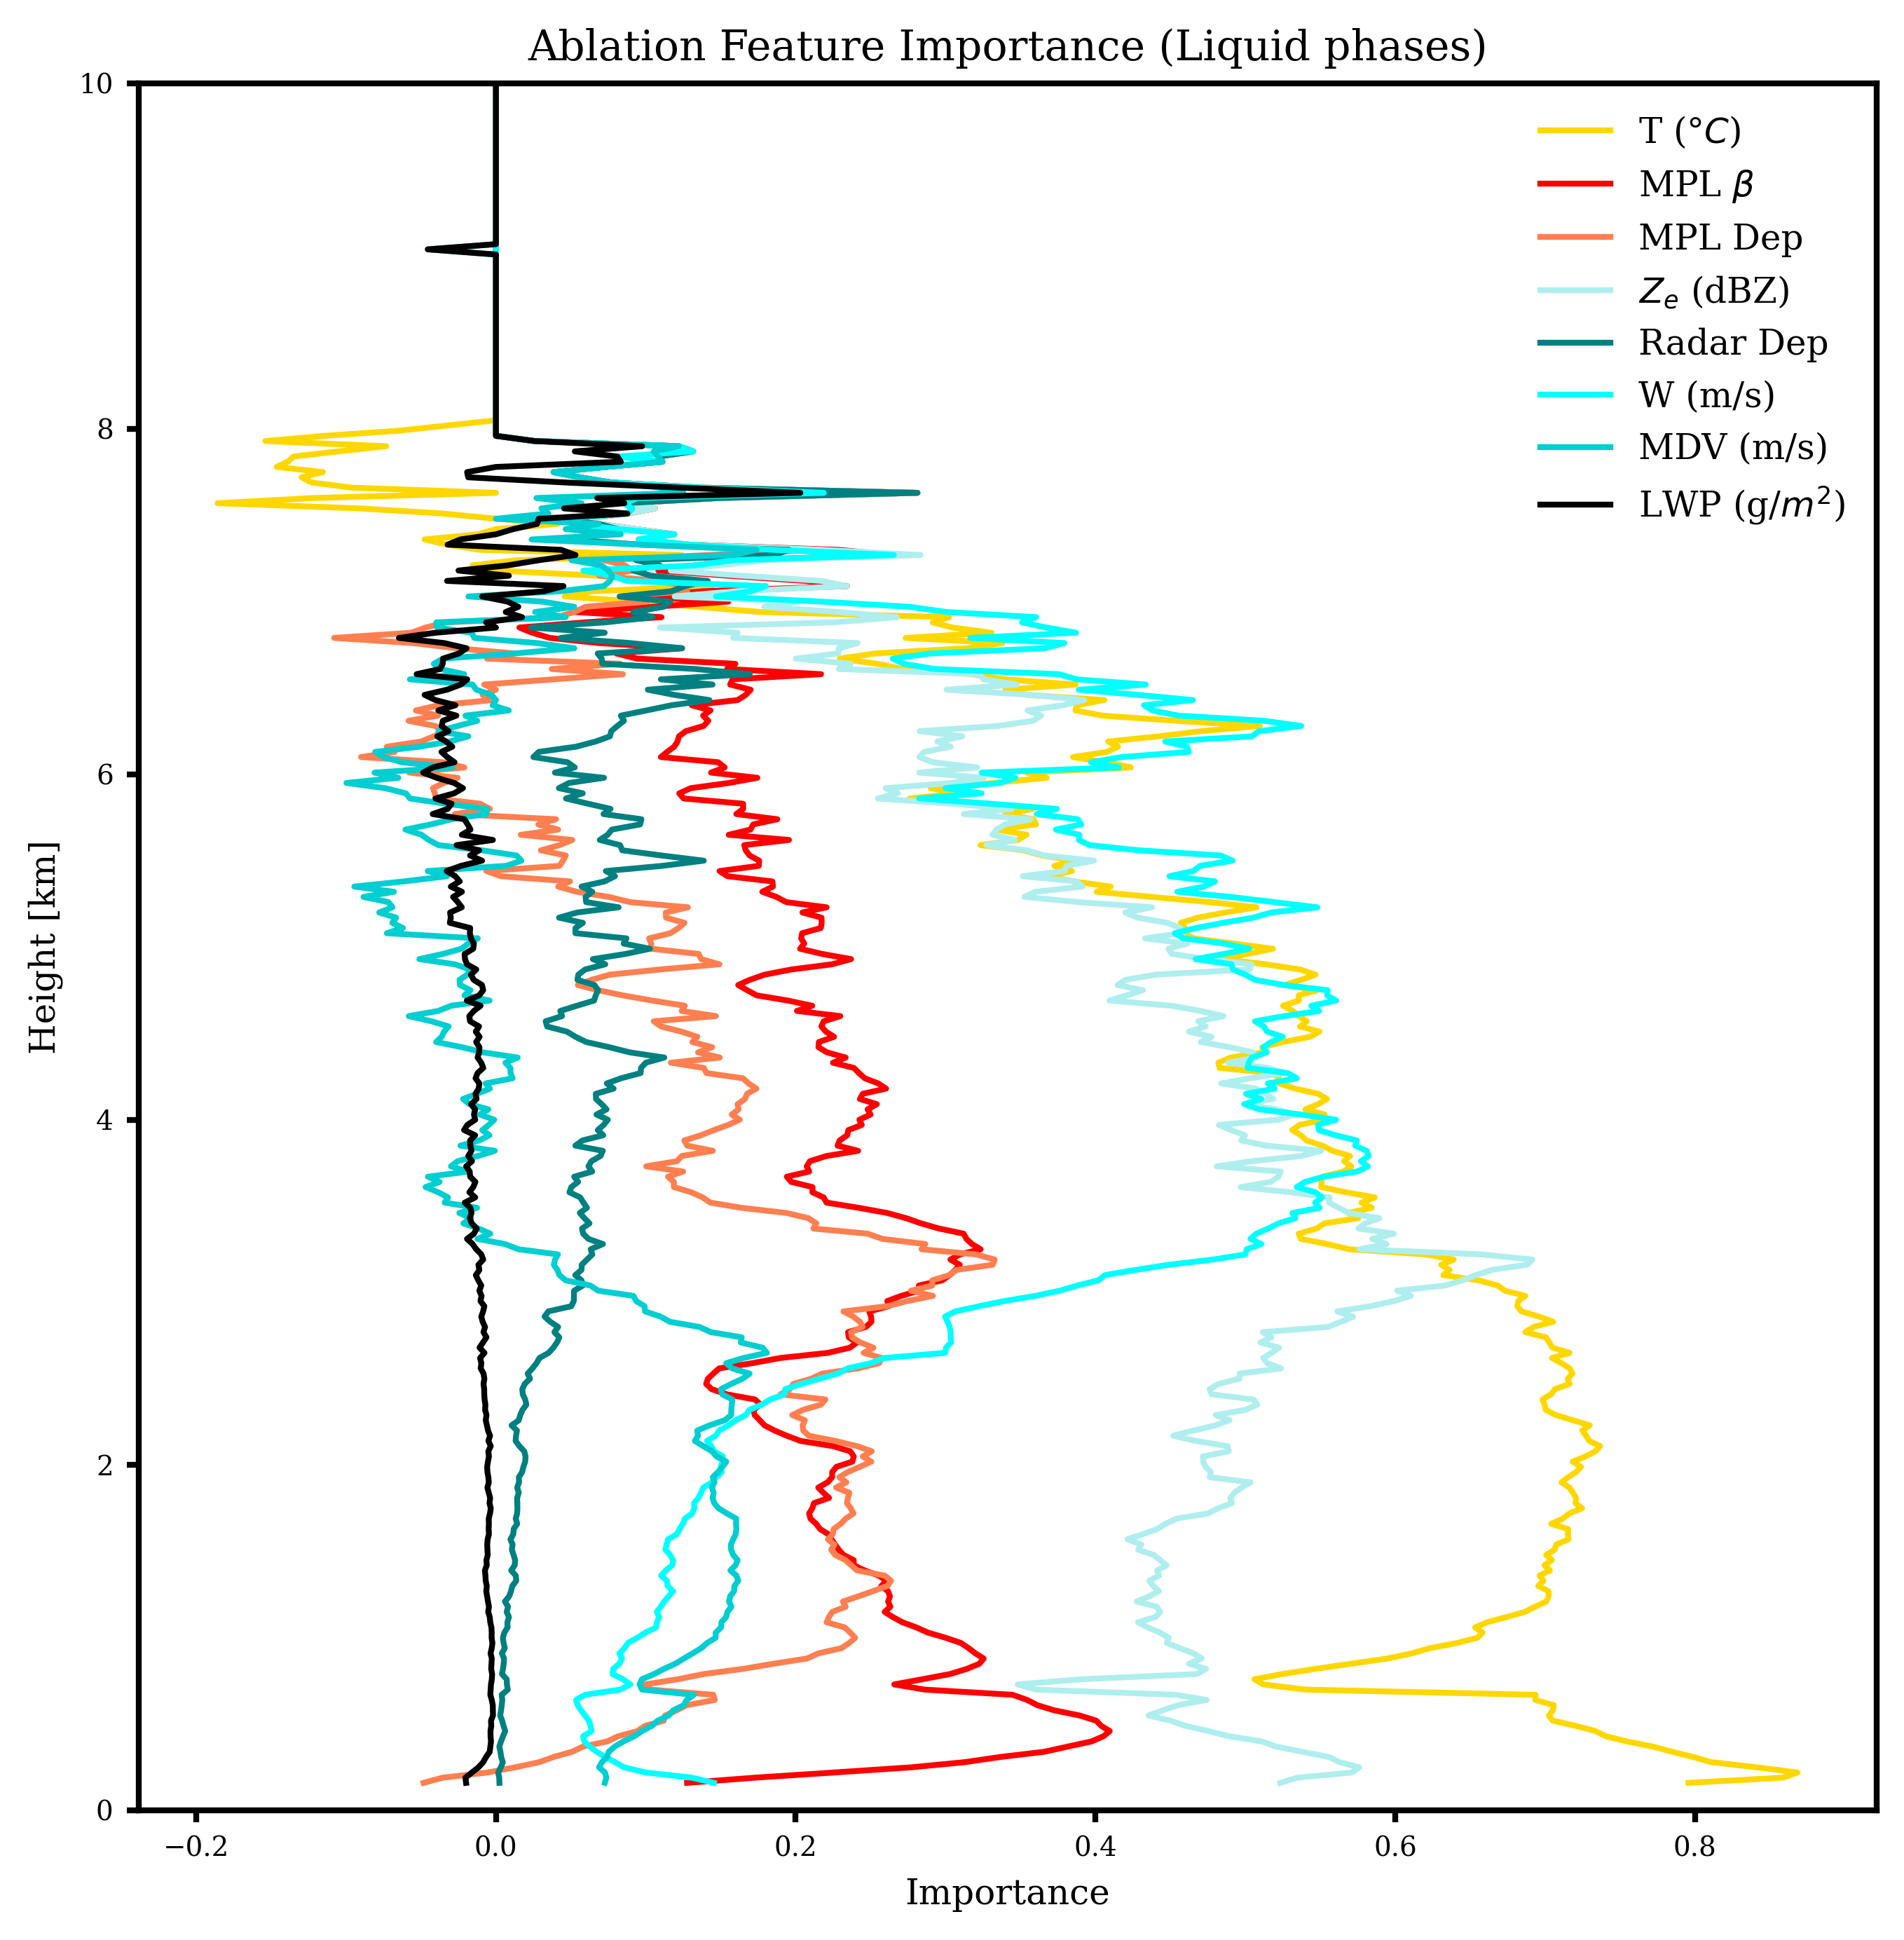

In [55]:
# Same as above, but limit to liquid phase types
fig, ax = plt.subplots()

pred_1yr_liq = pred_1yr[pred_1yr["cloud_phase"].isin(["liquid", "rain", "drizzle", "liq_driz"])]

height_acc_vec_overall = (pred_1yr_liq["cloud_phase"] == pred_1yr_liq["cnn"]).groupby(level="height").mean()

for var, (_, label, color) in tqdm(feature_display_map.items()):
    data = pred_1yr_liq["cnn_"+var]
    
    height_acc_vec = (pred_1yr_liq["cloud_phase"] == data).groupby(level="height").mean()
    height_importance_vec = height_acc_vec_overall - height_acc_vec

    ax.plot(height_importance_vec, height_importance_vec.index, label=label, color=color)

ax.legend(loc="best")
ax.set_xlabel("Importance")
ax.set_ylabel("Height [km]")
ax.set_title("Ablation Feature Importance (Liquid phases)")
# ax.set_xlim(0, None)
ax.set_ylim(0, 10)
# ax.set_yscale("log")
fig.show()